In [1]:
from pathlib import Path
import sys

library_dir = Path("../chapter_8_library")
dataset_dir = Path("../chapter_8_datasets")

if not library_dir.is_dir() or not dataset_dir.is_dir():
    raise FileNotFoundError(
        "This notebook expects local copies of 'chapter_8_library' and "
        "'chapter_8_datasets' in the project root."
    )

sys.path.append(str(library_dir.resolve()))

import matplotlib.pyplot as plt
import autograd.numpy as np
import section_8_3_helpers

plt.rcParams["figure.autolayout"] = True

dataset_path_2 = "../chapter_8_datasets/3d_span_data.csv"


In [2]:
# Proper linear autoencoder: optimize only C and recover W*(C) in closed form.
def autoencoder(C):
    W = np.linalg.solve(np.dot(C.T, C), np.dot(C.T, X))
    cost = np.sum((np.dot(C, W) - X) ** 2)
    return cost / float(X.shape[1])


In [3]:
# load in dataset
X_original = np.loadtxt(dataset_path_2, delimiter=",")

# center data
X_means = np.mean(X_original, axis=1)[:, np.newaxis]
X = X_original - X_means

# run gradient descent to minimize the autoencoder cost
g = autoencoder
max_its = 100
alpha_choice = 10 ** 0

# set up initialization for C only
np.random.seed(0)
scale = 0.1
C0 = scale * np.random.randn(3, 2)

# run gradient descent
weight_history, cost_history = section_8_3_helpers.gradient_descent(
    g, alpha_choice, max_its, C0
)

# use the learned 2D plane and compute the optimal decoder coordinates
C = np.asarray(weight_history[-1])
C, _ = np.linalg.qr(C)
C = C[:, :2]
W = np.linalg.solve(np.dot(C.T, C), np.dot(C.T, X))

# compare with the PCA solution on the same centered data
Cov = np.dot(X, X.T) / float(X.shape[1])
D, V = np.linalg.eigh(Cov)
order = np.argsort(D)[::-1]
D = D[order]
V = V[:, order]
C_pca = V[:, :2]

autoencoder_cost = np.sum((np.dot(C, W) - X) ** 2) / float(X.shape[1])
pca_residual = D[-1]
subspace_alignment = np.linalg.norm(np.dot(C.T, C_pca), ord="fro") / np.sqrt(2.0)

print(f"Initial autoencoder cost: {float(np.asarray(cost_history[0]).reshape(-1)[0]):.6f}")
print(f"Final autoencoder cost: {float(autoencoder_cost):.6f}")
print(f"Rank-2 PCA residual variance: {float(pca_residual):.6f}")
print(f"Subspace alignment with PCA plane: {float(subspace_alignment):.6f}")


Initial autoencoder cost: 0.523823
Final autoencoder cost: 0.317962
Rank-2 PCA residual variance: 0.317962
Subspace alignment with PCA plane: 1.000000


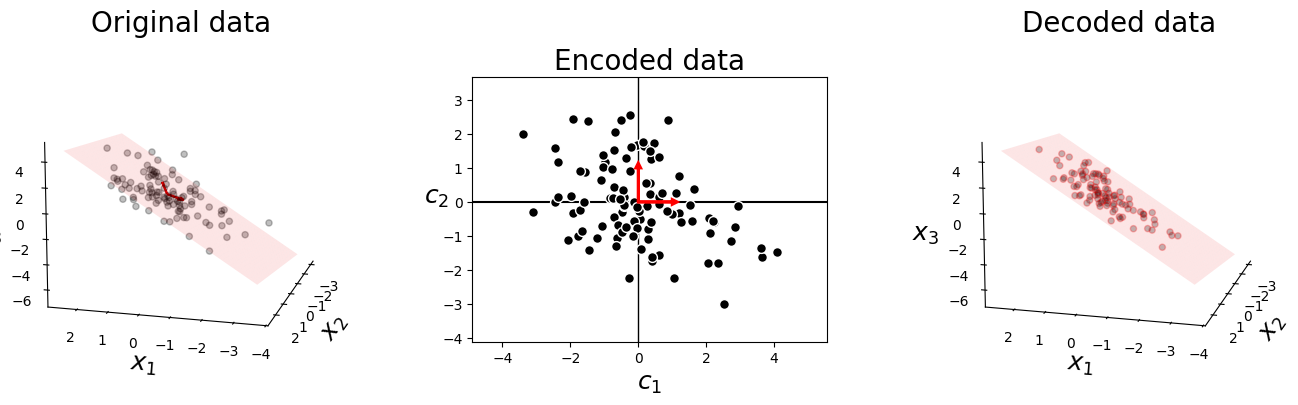

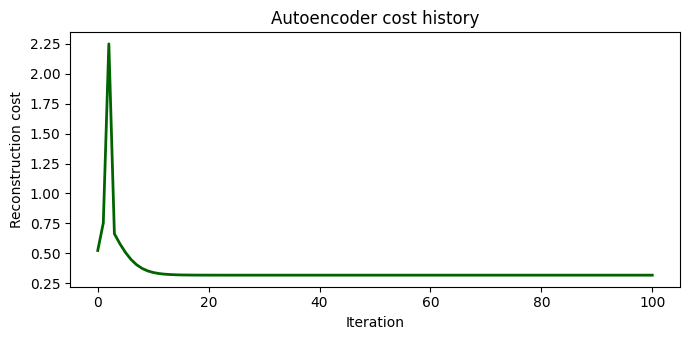

In [4]:
# produce visuals using the learned encoder plane
view = [15, 105]
section_8_3_helpers.project_data_from_3d_to_2d(X, C, view)

plt.figure(figsize=(7, 3.5))
plt.plot(cost_history, linewidth=2, color="darkgreen")
plt.xlabel("Iteration")
plt.ylabel("Reconstruction cost")
plt.title("Autoencoder cost history")
plt.show()


In [5]:
print(
    "This completed version optimizes only C. At every evaluation, the latent coordinates "
    "W*(C) = (C^T C)^(-1) C^T X are recomputed from the current encoder matrix, which makes "
    "the notebook a proper linear autoencoder rather than a free low-rank factorization."
)


This completed version optimizes only C. At every evaluation, the latent coordinates W*(C) = (C^T C)^(-1) C^T X are recomputed from the current encoder matrix, which makes the notebook a proper linear autoencoder rather than a free low-rank factorization.
